In [1]:
!pip install -q transformers open_clip_torch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

import torch

from transformers import (
    CLIPModel,
    CLIPProcessor,
    AutoModel,
    AutoProcessor
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"remzbek","key":"44acbf90ada753990601baf3af282860"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:04<00:00, 176MB/s]



In [7]:
!unzip -q cell-images-for-detecting-malaria.zip

In [8]:
base_dir = "/content/cell_images"

classes = ["Parasitized", "Uninfected"]

image_paths = []
labels = []

for label in classes:

    folder = os.path.join(base_dir, label)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        image_paths.append(path)
        labels.append(label)

print("Toplam görüntü:", len(image_paths))

Toplam görüntü: 27560


In [22]:
print(os.listdir("/content/cell_images"))

['Uninfected', 'Parasitized']


In [23]:
base_dir = "/content/cell_images"

classes = [
    "Parasitized",
    "Uninfected"
]

image_paths = []
labels = []

valid_extensions = (
    ".png",
    ".jpg",
    ".jpeg"
)

for label in classes:

    folder = os.path.join(base_dir, label)

    for file in os.listdir(folder):

        file_lower = file.lower()

        # sadece image dosyalarını al
        if file_lower.endswith(valid_extensions):

            path = os.path.join(folder, file)

            image_paths.append(path)
            labels.append(label)

print("Toplam görüntü:", len(image_paths))

Toplam görüntü: 27558


In [24]:
df = pd.DataFrame({
    "image": image_paths,
    "label": labels
})

df.head()

,image,label
0,/content/cell_images/Parasitized/C48P9thinF_IM...,Parasitized
1,/content/cell_images/Parasitized/C68P29N_ThinF...,Parasitized
2,/content/cell_images/Parasitized/C179P140ThinF...,Parasitized
3,/content/cell_images/Parasitized/C59P20thinF_I...,Parasitized
4,/content/cell_images/Parasitized/C126P87ThinF_...,Parasitized


In [25]:
_, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Test görüntü sayısı:", len(test_df))

Test görüntü sayısı: 5512


In [26]:
prompt_sets = {

    "short_prompts": [

        "parasitized cell",
        "uninfected cell"

    ],

    "descriptive_prompts": [

        "a microscopy image showing malaria infected red blood cell",

        "a microscopy image showing healthy red blood cell"
    ]
}

In [27]:
clip_model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(
    clip_model_name
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    clip_model_name
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
def evaluate_clip_model(
    model,
    processor,
    prompts,
    test_df,
    class_names
):

    # --------------------------------
    # TEXT INPUTS
    # --------------------------------

    text_inputs = processor(
        text=prompts,
        return_tensors="pt",
        padding=True
    )

    text_inputs = {
        k: v.to(device)
        for k, v in text_inputs.items()
    }

    # --------------------------------
    # TEXT FEATURES
    # --------------------------------

    with torch.no_grad():

        text_outputs = model.text_model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"]
        )

        # pooled output
        text_features = text_outputs.pooler_output

        # projection layer
        text_features = model.text_projection(
            text_features
        )

    # normalize
    text_features = text_features / text_features.norm(
        dim=-1,
        keepdim=True
    )

    # --------------------------------
    # PREDICTION LOOP
    # --------------------------------

    y_true = []
    y_pred = []

    skipped = 0

    for _, row in tqdm(
        test_df.iterrows(),
        total=len(test_df)
    ):

        try:

            image = Image.open(
                row["image"]
            ).convert("RGB")

            image_inputs = processor(
                images=image,
                return_tensors="pt"
            )

            image_inputs = {
                k: v.to(device)
                for k, v in image_inputs.items()
            }

            with torch.no_grad():

                image_outputs = model.vision_model(
                    pixel_values=image_inputs["pixel_values"]
                )

                image_features = image_outputs.pooler_output

                image_features = model.visual_projection(
                    image_features
                )

            # normalize
            image_features = image_features / image_features.norm(
                dim=-1,
                keepdim=True
            )

            # cosine similarity
            similarity = image_features @ text_features.T

            pred_idx = similarity.argmax(
                dim=1
            ).item()

            pred_label = class_names[pred_idx]

            y_true.append(row["label"])
            y_pred.append(pred_label)

        except Exception as e:

            skipped += 1

            print("Skipped:", row["image"])

    print("Skipped files:", skipped)

    return y_true, y_pred

In [31]:
class_names = [
    "Parasitized",
    "Uninfected"
]

short_prompts = prompt_sets["short_prompts"]

y_true_short, y_pred_short = evaluate_clip_model(
    clip_model,
    clip_processor,
    short_prompts,
    test_df,
    class_names
)

100%|██████████| 5512/5512 [01:04<00:00, 85.03it/s]

Skipped files: 0


In [32]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [33]:
acc = accuracy_score(y_true_short, y_pred_short)

f1 = f1_score(y_true_short, y_pred_short, average="macro")

print("Accuracy:", acc)
print("Macro F1:", f1)

Accuracy: 0.4553701015965167
Macro F1: 0.33957936211449247


In [34]:
print(classification_report(y_true_short, y_pred_short))

              precision    recall  f1-score   support

 Parasitized       0.48      0.87      0.62      2756
  Uninfected       0.23      0.04      0.06      2756

    accuracy                           0.46      5512
   macro avg       0.35      0.46      0.34      5512
weighted avg       0.35      0.46      0.34      5512



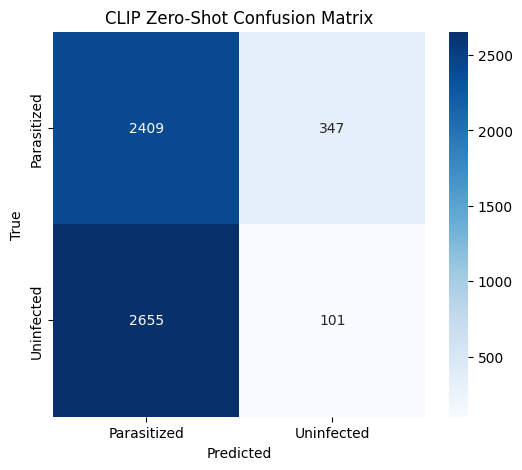

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["Parasitized", "Uninfected"]

cm = confusion_matrix(y_true_short, y_pred_short)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CLIP Zero-Shot Confusion Matrix")
plt.show()

In [36]:
descriptive_prompts = [
    "a microscopy image showing malaria infected red blood cell",
    "a microscopy image showing healthy red blood cell"
]

In [37]:
y_true_desc, y_pred_desc = evaluate_clip_model(
    clip_model,
    clip_processor,
    descriptive_prompts,
    test_df,
    class_names
)

100%|██████████| 5512/5512 [01:07<00:00, 81.40it/s]

Skipped files: 0


In [38]:
acc_desc = accuracy_score(y_true_desc, y_pred_desc)
f1_desc = f1_score(y_true_desc, y_pred_desc, average="macro")

print("Descriptive Prompt Accuracy:", acc_desc)
print("Descriptive Prompt Macro F1:", f1_desc)

Descriptive Prompt Accuracy: 0.7639695210449927
Descriptive Prompt Macro F1: 0.7595050771605729


In [39]:
results = pd.DataFrame({
    "Prompt Type": ["Short Prompt", "Descriptive Prompt"],
    "Accuracy": [acc, acc_desc],
    "Macro F1": [f1, f1_desc]
})

results

,Prompt Type,Accuracy,Macro F1
0,Short Prompt,0.45537,0.339579
1,Descriptive Prompt,0.76397,0.759505


In [40]:
wrong_indices = [
    i for i in range(len(y_true_short))
    if y_true_short[i] != y_pred_short[i]
]

print("Yanlış tahmin sayısı:", len(wrong_indices))

Yanlış tahmin sayısı: 3002


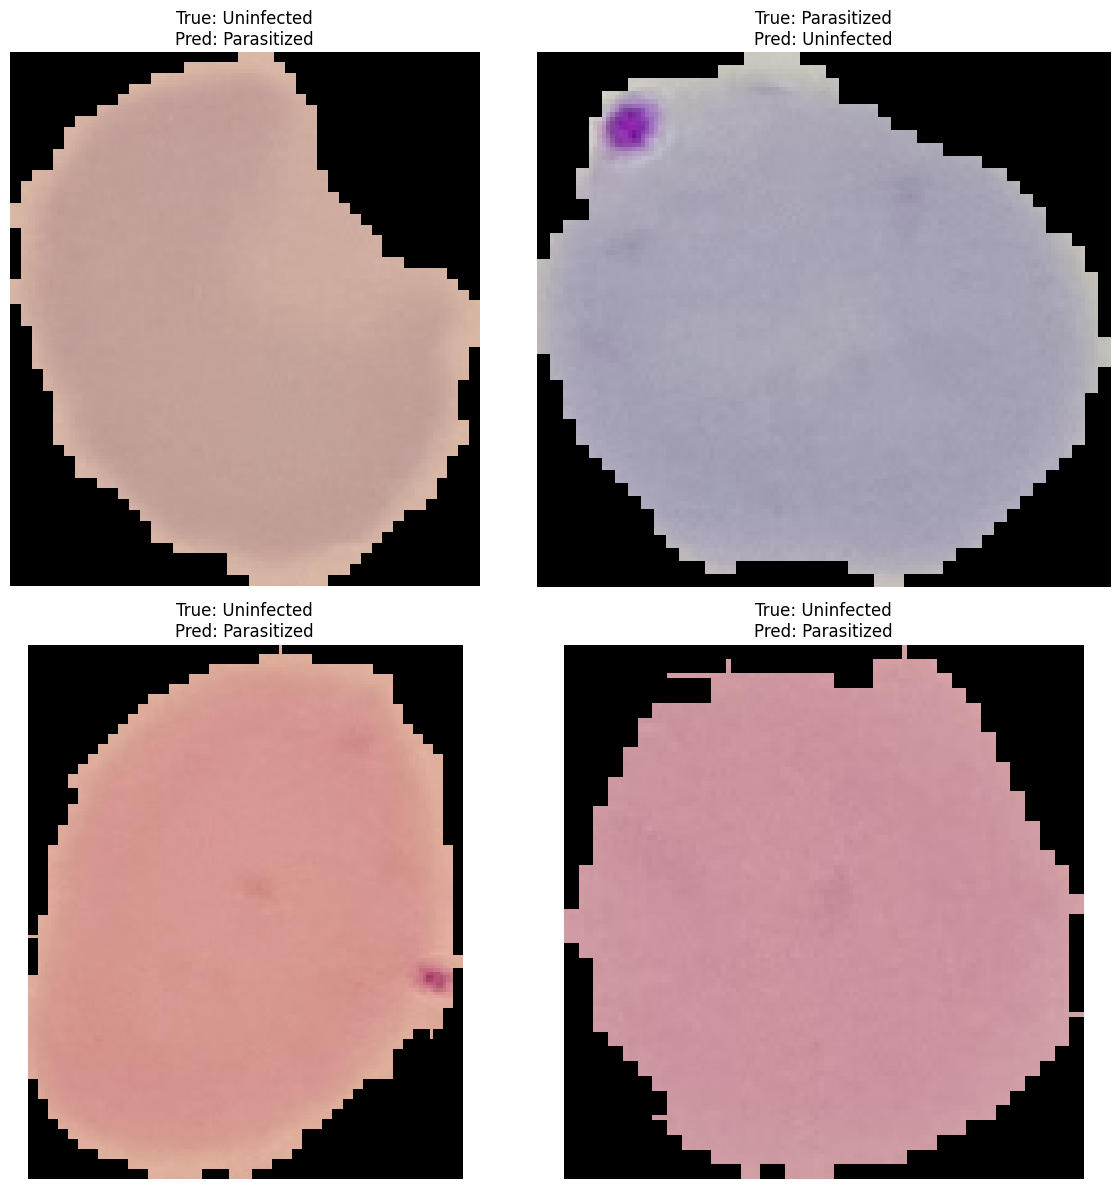

In [41]:
import random
from PIL import Image

sample = random.sample(wrong_indices, 4)

plt.figure(figsize=(12,12))

for i, idx in enumerate(sample):

    img_path = test_df.iloc[idx]["image"]
    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"True: {y_true_short[idx]}\nPred: {y_pred_short[idx]}"
    )

plt.tight_layout()
plt.show()